# 1. Engine Implementation
*(Core Monte Carlo logic and combat rules. Run this once, then scroll down to configure and run encounters.)*

In [1]:
import random
import re
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_max_health(actor):
    t = actor.get('t', 'M').upper()
    d = actor.get('dur', 0)
    if t == 'A': return d * 4
    elif t == 'B': return d * 3 + 10
    elif t == 'L': return d * 2 + 10
    return d

def resolve_initiative(init_string):
    match = re.match(r'(\d+)\((\d+)\)', str(init_string))
    if match: return (int(match.group(1)) * 2) + int(match.group(2))
    return 0

def calculate_wound_dice_penalty(actor, current_hp, max_hp):
    t = actor.get('t', 'M').upper()
    hp_pct = current_hp / max_hp if max_hp > 0 else 0
    if t == 'A':
        if hp_pct < 0.25: return 2
        if hp_pct < 0.50: return 1
    elif t == 'B':
        if hp_pct < 0.333: return 2
        if hp_pct < 0.666: return 1
    elif t in ('L', 'M'):
        if hp_pct < 0.50: return 1
    return 0

def roll_attack_successes(base_dice, target_num, penalty, environment_mod):
    final_dice = max(0, base_dice - penalty + environment_mod)
    successes = 0
    if final_dice <= 0: # 0 Dice Roll Mechanics
        worst_roll = max(random.randint(1, 20), random.randint(1, 20))
        if worst_roll == target_num: successes += 2
        elif worst_roll < target_num: successes += 1
    else:
        for _ in range(final_dice):
            roll = random.randint(1, 20)
            if roll == target_num: successes += 2
            elif roll < target_num: successes += 1
    return successes

def get_primary_target(targets, focus_type, team):
    living = [t for t in targets if t['current_hp'] > 0]
    if not living: return None

    if focus_type == "Highest HP":
        return max(living, key=lambda t: t['current_hp'])
    elif focus_type == "Lowest HP":
        return min(living, key=lambda t: t['current_hp'])
    elif focus_type == "Highest Priority":
        living_with_priority = [t for t in living if 'pri' in t]
        if living_with_priority:
            return min(living_with_priority, key=lambda t: t.get('pri', 99))
        else:
            return None
    else:
        return None

def pick_target(targets, original_team_size):
    living = [t for t in targets if t['current_hp'] > 0]
    if not living: return None
    
    living_count = len(living)
    weights = []
    
    for t in living:
        factor_array = t.get('tf', [0])
        # Calculate the dynamic lookup index.
        # e.g., Started with 3. If 3 are alive, index is 0. If 1 is alive, index is 2.
        # Fallback clamped to max array length mapping to avoid index out of bounds.
        index = (original_team_size - living_count)
        index = max(0, min(index, len(factor_array) - 1))
        
        weights.append(factor_array[index])
        
    if sum(weights) == 0: return random.choice(living) # 0 Instance Target Factor Fix
    return random.choices(living, weights=weights, k=1)[0]

def parse_damage(damage_stat):
    match = re.match(r'(\d+)(?:\((\d+)\))?', str(damage_stat))
    return (int(match.group(1)), int(match.group(2)) if match.group(2) else 1) if match else (0, 1)

def apply_damage(target, raw_damage):
    target['current_hp'] = max(0, target['current_hp'] - max(0, raw_damage - target.get('mit', 0)))

def sim_combat(party_data, monster_data, max_rounds, p_env, m_env, p_focus='None', m_focus='None'):
    p_roster = copy.deepcopy(party_data)
    m_roster = copy.deepcopy(monster_data)
    
    original_party_size = len(p_roster)
    original_monster_size = len(m_roster)
    
    for p in p_roster:
        p['max_hp'] = calculate_max_health(p)
        p['current_hp'] = p['max_hp']
        p['init_score'] = resolve_initiative(p['ini'])
        p['is_pc'] = True
        
    for m in m_roster:
        m['max_hp'] = calculate_max_health(m)
        m['current_hp'] = m['max_hp']
        m['init_score'] = resolve_initiative(m['ini'])
        m['is_pc'] = False

    all_combatants = p_roster + m_roster
    random.shuffle(all_combatants) # Resolves identical initiative scores arbitrarily
    all_combatants.sort(key=lambda x: (x['init_score'], x['is_pc']), reverse=True) # PCs win Ties
    
    rounds_fought = 0
    while rounds_fought < max_rounds:
        rounds_fought += 1
        p_mod = p_env[min(rounds_fought-1, len(p_env)-1)]
        m_mod = m_env[min(rounds_fought-1, len(m_env)-1)]
        
        for actor in all_combatants:
            if actor['current_hp'] <= 0: continue
            
            # Identify Targets and Original Group sizes for 'Ally Down' aggro scaling
            if actor['is_pc']:
                target_pool = m_roster
                env_mod = p_mod
                team_size = original_monster_size
            else:
                target_pool = p_roster
                env_mod = m_mod
                team_size = original_party_size
            
            targets = [t for t in target_pool if t['current_hp'] > 0]
            if not targets: continue
            
            penalty = calculate_wound_dice_penalty(actor, actor['current_hp'], actor['max_hp'])
            successes = roll_attack_successes(actor['d'], actor['tgt'], penalty, env_mod)
            
            if successes > 0:
                base_dmg, max_t = parse_damage(actor['dam'])
                focus_factor = actor.get('ff', 0)
                focus_type = p_focus if actor['is_pc'] else m_focus
                
                for _ in range(max_t):
                    target = None
                    if random.randint(1, 100) <= focus_factor:
                        target = get_primary_target(targets, focus_type, team_size)
                    
                    if not target:
                        target = pick_target(targets, team_size)
                        
                    if target: apply_damage(target, base_dmg * successes)
                    
        p_alive = any(p['current_hp'] > 0 for p in p_roster)
        m_alive = any(m['current_hp'] > 0 for m in m_roster)
        
        if not p_alive: return {"outcome": "Monsters Win", "rounds": rounds_fought, "party": p_roster}
        if not m_alive: return {"outcome": "Party Wins", "rounds": rounds_fought, "party": p_roster}
            
    return {"outcome": "Time Out", "rounds": rounds_fought, "party": p_roster}

def run_monte_carlo(party, monsters, max_rounds, p_env, m_env, p_focus='None', m_focus='None', sim_count=1000):
    """
    Runs the combat loop N times and returns arrays of the outcomes for plotting.
    """
    results = []
    party_final_states = []
    
    for _ in range(sim_count):
        res = sim_combat(party, monsters, max_rounds, p_env, m_env, p_focus, m_focus)
        results.append(res)
        
        if res['outcome'] == "Party Wins":
            party_final_states.append(res['party'])
            
    return results, party_final_states

def render_encounter_analysis(party, monsters, max_rounds, p_env, m_env, p_focus, m_focus, sim_count):
    # Run the simulations
    results, victorious_parties = run_monte_carlo(party, monsters, max_rounds, p_env, m_env, p_focus, m_focus, sim_count=sim_count)
    print(f"Ran {sim_count:,} simulations.")

    # Format result data
    df_results = pd.DataFrame(results)
    win_rates = df_results['outcome'].value_counts(normalize=True) * 100

    print("\n--- OVERALL WIN DISTRIBUTION ---")
    print(win_rates)

    # Calculate Player Death Risk and HP data from Victorious fights
    party_names = [p['name'] for p in party]
    player_stats = {name: {'deaths': 0, 'hp_array': []} for name in party_names}
    victorious_count = len(victorious_parties)

    for final_roster in victorious_parties:
        for p in final_roster:
            if p['current_hp'] <= 0:
                player_stats[p['name']]['deaths'] += 1
            else:
                player_stats[p['name']]['hp_array'].append(p['current_hp'])

    cell_text = []
    box_data = []

    for name, stats in player_stats.items():
        death_pct = (stats['deaths'] / victorious_count * 100) if victorious_count > 0 else 0
        cell_text.append([name, f"{death_pct:05.2f}%"])
        for hp in stats['hp_array']:
            box_data.append({'Player': name, 'Remaining HP': hp})

    # Render Visualizations
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 1.5, 1.5]})
    win_pct = win_rates.get('Party Wins', 0.0)
    fig.suptitle(f"Encounter Results ({sim_count:,} simulated fights)\nParty Overall Win Rate: {win_pct:05.2f}%", fontsize=15, weight='bold', y=1.05)

    # 1. Death Risk Table
    ax_text = axes[0]
    ax_text.axis('off')

    col_labels = ["Player Name", "Death Risk (On Win)"]
    table = ax_text.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 4.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e6e6e6')

    # 2. Remaining Health Boxplot
    ax_box = axes[1]
    box_df = pd.DataFrame(box_data)

    if not box_df.empty:
        sns.boxplot(
            data=box_df, 
            x='Player', 
            y='Remaining HP', 
            ax=ax_box,
            color='#4d94ff',
            order=party_names
        )
        
        ax_box.axhline(0, color='red', linestyle='--', linewidth=2)
        ax_box.set_xlabel('')
        ax_box.set_title("Player Health (Victorious Fights)")
        ax_box.grid(axis='y', linestyle='--', alpha=0.7)

    # 3. Rounds Fought Stacked Bar Chart
    ax_rounds = axes[2]
    
    # Restructure data for round termination chances
    round_counts = df_results.groupby(["rounds", "outcome"]).size().unstack(fill_value=0)
    round_pcts = (round_counts / sim_count) * 100
    
    # Ensure all rounds 1 through max_rounds are present in the dataframe
    for r in range(1, max_rounds + 1):
        if r not in round_pcts.index:
            round_pcts.loc[r] = [0, 0, 0] if len(round_pcts.columns) == 3 else pd.Series(dtype=float)
            
    round_pcts = round_pcts.sort_index()

    # Define strict color mapping
    color_map = {
        "Party Wins": "#2ca02c",    # Green
        "Monsters Win": "#d62728",  # Red
        "Time Out": "#ff7f0e"       # Orange/Yellow
    }
    
    # Filter the color map to only columns that actually appeared
    plot_colors = [color_map.get(col, "#cccccc") for col in round_pcts.columns]
    
    round_pcts.plot(
        kind='bar', 
        stacked=True, 
        ax=ax_rounds, 
        color=plot_colors,
        width=0.8
    )
    
    ax_rounds.set_title("Chances of Combat Ending Per Round")
    ax_rounds.set_xlabel("Round Number")
    ax_rounds.set_ylabel("Probability (%)")
    ax_rounds.tick_params(axis='x', rotation=0)
    ax_rounds.legend(title="Outcome", loc="upper left", bbox_to_anchor=(1, 1))
    ax_rounds.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


# 2. Combat Simulator: Encounter Configuration & Outcomes
Define the global parameters, execute the cell, and the Monte Carlo visualizations will generate immediately beneath it!

Ran 5,000 simulations.

--- OVERALL WIN DISTRIBUTION ---
outcome
Party Wins      65.66
Monsters Win    32.72
Time Out         1.62
Name: proportion, dtype: float64


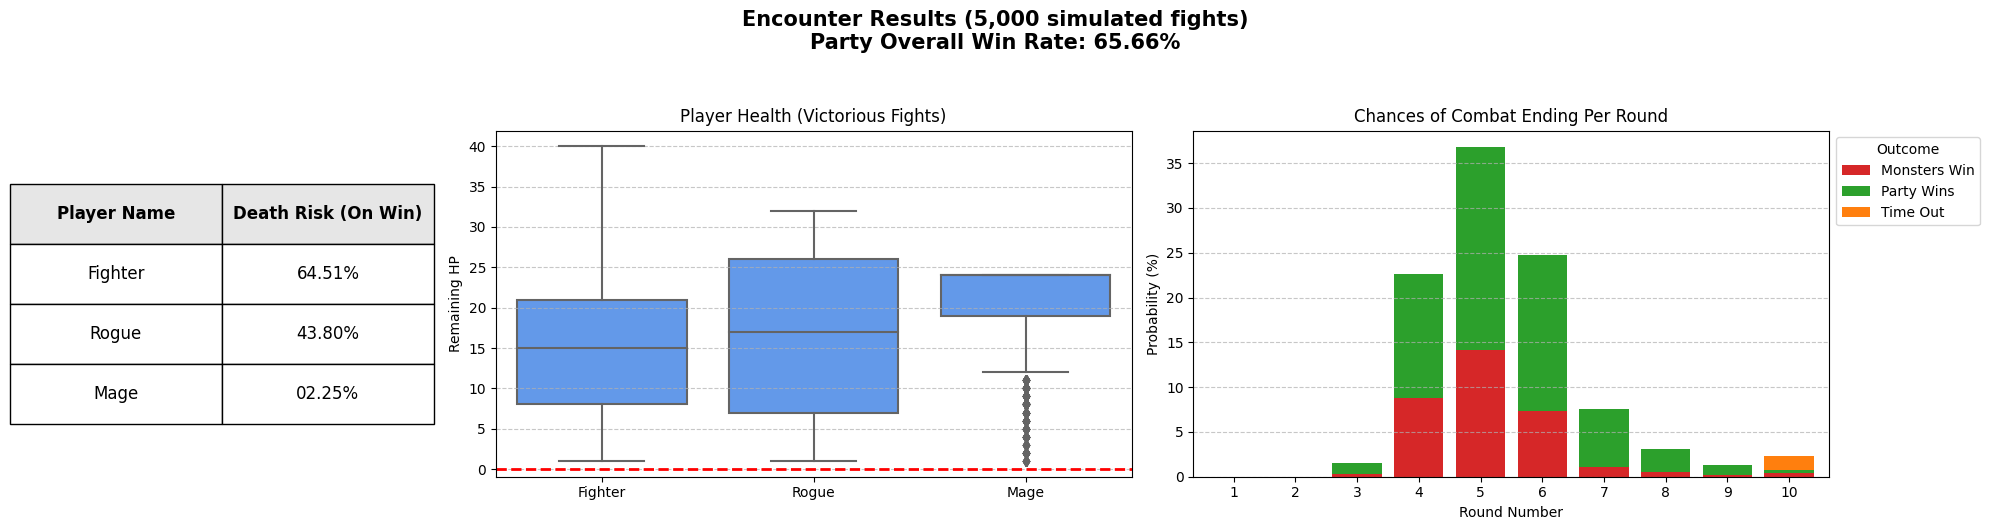

In [2]:
# Global Encounter Parameters
MaxRounds = 10
simulations_to_run = 5000

# Environment Variables (Dice Adjustments per round)
player_enviroment_factor = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
monster_enviroment_factor = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
player_focus = "Highest Priority"
monster_focus = "Lowest HP"

# Combatant Profiles
party = [
    {"name": "Fighter", "t": "A", "d": 3, "tgt": 12, "dam": 4, "dur": 10, "mit": 1, "ini": "3(10)", "tf": [6, 6, 6], "ff": 80, "pri": 1},
    {"name": "Rogue", "t": "A", "d": 3, "tgt": 10, "dam": 3, "dur": 8, "mit": 0, "ini": "4(12)", "tf": [2, 4, 5], "ff": 80, "pri": 2},
    {"name": "Mage", "t": "A", "d": 3, "tgt": 15, "dam": "3(2)", "dur": 6, "mit": 0, "ini": "2(10)", "tf": [0, 0, 0], "ff": 80, "pri": 3}
]

monsters = [
    {"name": "Goblin Boss", "t": "B", "d": 8, "tgt": 14, "dam": 4, "dur": 9, "mit": 2, "ini": "4(12)", "tf": [1, 1, 1, 1], "ff": 20, "pri": 1},
    {"name": "Goblin Lieutenant", "t": "L", "d": 1, "tgt": 12, "dam": 3, "dur": 8, "mit": 1, "ini": "3(10)", "tf": [1, 1, 1, 1], "ff": 20, "pri": 2},
    {"name": "Goblin Minion 1", "t": "M", "d": 1, "tgt": 10, "dam": 2, "dur": 5, "mit": 0, "ini": "2(8)", "tf": [1, 1, 1, 1], "ff": 20, "pri": 2},
    {"name": "Goblin Minion 2", "t": "M", "d": 1, "tgt": 10, "dam": 2, "dur": 5, "mit": 0, "ini": "2(8)", "tf": [1, 1, 1, 1], "ff": 20, "pri": 2}
]

# Run analysis
render_encounter_analysis(
    party=party,
    monsters=monsters,
    max_rounds=MaxRounds,
    p_env=player_enviroment_factor,
    m_env=monster_enviroment_factor,
    p_focus=player_focus,
    m_focus=monster_focus,
    sim_count=simulations_to_run
)
